In [2]:
! pip install -U torchvision
!pip install -U torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 5.3 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 3.7 MB/s  0:02:03m0:00:0100:04
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 4.8 MB/s  0:00:39m0:00:0100:02
  Attempting uninstall: triton
    Found existing installation: triton 3.7.0
    Uninstalling triton-3.7.0:
      Successfully uninstalled triton-3.7.0
  Attempting uninstall: torch━━━━━━━━━━━━━━━━━━━ 0/3 [triton]
    Found existing installation: torch 2.12.0 0/3 [triton]
    Uninstalling torch-2.12.0:╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [torch]
      Successfully uninstalled torch-2.12.0━━━━━━━━━━━━━━━━━━━ 1/3 [torch]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [torchvision] [torchvision]


In [3]:
# 1: Bib
import pandas as pd
import numpy as np

from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision.models import resnet18


In [5]:
# 2: CSV laden

df = pd.read_csv("dataset/labels.csv")

df.head()

# check:
print(df.shape)

(347085, 4)


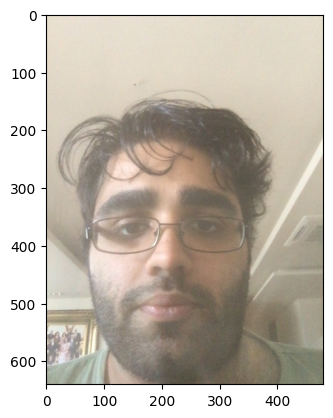

160.0 284.0


In [6]:
# 3: check a image

row = df.iloc[0]

img = Image.open(row["image_name"])

plt.imshow(img)
plt.show()

print(row["x"], row["y"])

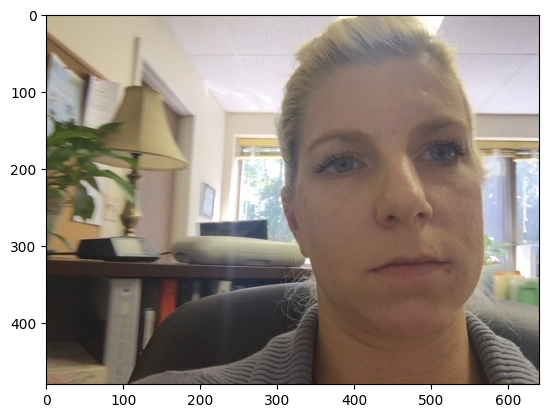

304.468243182 180.574068725


In [9]:
row = df.iloc[100000]

img = Image.open(row["image_name"])

plt.imshow(img)
plt.show()

print(row["x"], row["y"])

In [10]:
# 4: Dataset Class: transfer CSV in PyTorch.

class GazeDataset(Dataset):

    def __init__(self, csv_file, transform=None):

        self.df = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = Image.open(
            row["image_name"]
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        target = torch.tensor(
            [
                row["x"],
                row["y"]
            ],
            dtype=torch.float32
        )

        return image, target

In [11]:
# 5: DataLoader

# Transformationen:

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])


# Dataset:

train_dataset = GazeDataset(
    "./splits/subject_train.csv",
    transform
)

test_dataset = GazeDataset(
    "./splits/subject_test.csv",
    transform
)


# Loader:

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)


In [12]:
# 6: ResNet18 (Pretrainiertes Modell):

from torchvision.models import (
    resnet18,
    ResNet18_Weights
)

# Load:

model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

# last layer Original: 512 → 1000, but we need: 512 → 2 (for x, y)

model.fc = nn.Linear(
    model.fc.in_features,
    2
)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/ari/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:10<00:00, 4.56MB/s]


In [13]:
# 7: GPU

# check:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [14]:
# 8: Loss and Optimizer

# for regression:
# criterion = nn.MSELoss()

criterion = nn.SmoothL1Loss()

# Optimizer:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)


In [ ]:
# 9: Training

epochs = 10

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, targets in train_loader:

        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        preds = model(images)

        loss = criterion(
            preds,
            targets
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        epoch,
        running_loss
    )

In [ ]:
# 10: Evaluation

model.eval()

image, target = test_dataset[0]

with torch.no_grad():

    pred = model(
        image.unsqueeze(0).to(device)
    )

print("True :", target)
print("Pred :", pred)

In [ ]:
resnet = models.resnet18(weights="IMAGENET1K_V1")
